In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from seaborn import color_palette

In [2]:
NEUTRAL_SENTIMENT_COLOR = color_palette()[0]
POSITIVE_SENTIMENT_COLOR = color_palette()[2]
NEGATIVE_SENTIMENT_COLOR = color_palette()[1]

SENTIMENT_PALETTE = [
    NEUTRAL_SENTIMENT_COLOR,
    POSITIVE_SENTIMENT_COLOR,
    NEGATIVE_SENTIMENT_COLOR,
]

PLOT_SENTIMENT_LABELS = ["Positivo", "Negativo", "Neutro"]

In [3]:
metrics_df = pd.DataFrame(
    {
        "Tipo de Treinamento": [
            "Desbalanceado\nsem congelamento",
            "Desbalanceado\nsem congelamento",
            "Desbalanceado\nsem congelamento",
            "Desbalanceado\ncom congelamento",
            "Desbalanceado\ncom congelamento",
            "Desbalanceado\ncom congelamento",
            "Oversampling\nsem congelamento",
            "Oversampling\nsem congelamento",
            "Oversampling\nsem congelamento",
            "Oversampling\ncom congelamento",
            "Oversampling\ncom congelamento",
            "Oversampling\ncom congelamento",
        ],
        "Classe": [
            "Positivo",
            "Negativo",
            "Neutro",
            "Positivo",
            "Negativo",
            "Neutro",
            "Positivo",
            "Negativo",
            "Neutro",
            "Positivo",
            "Negativo",
            "Neutro",
        ],
        "Pontuação F1": [
            0.96,
            0.94,
            0.76,
            0.95,
            0.94,
            0.84,
            0.95,
            0.93,
            0.96,
            0.96,
            0.96,
            0.98,
        ],
    }
)

In [4]:
metrics_df

,Tipo de Treinamento,Classe,Pontuação F1
0,Desbalanceado\nsem congelamento,Positivo,0.96
1,Desbalanceado\nsem congelamento,Negativo,0.94
2,Desbalanceado\nsem congelamento,Neutro,0.76
3,Desbalanceado\ncom congelamento,Positivo,0.95
4,Desbalanceado\ncom congelamento,Negativo,0.94
5,Desbalanceado\ncom congelamento,Neutro,0.84
6,Oversampling\nsem congelamento,Positivo,0.95
7,Oversampling\nsem congelamento,Negativo,0.93
8,Oversampling\nsem congelamento,Neutro,0.96
9,Oversampling\ncom congelamento,Positivo,0.96


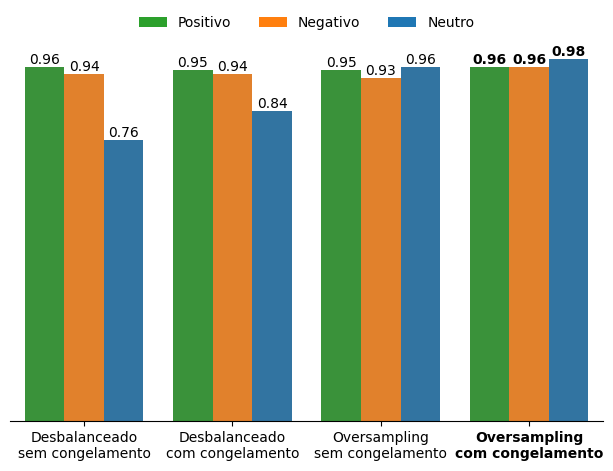

In [6]:
fig, ax = plt.subplots(1)

bars = sns.barplot(
    data=metrics_df,
    x="Tipo de Treinamento",
    y="Pontuação F1",
    hue="Classe",
    ax=ax,
    palette=[
        POSITIVE_SENTIMENT_COLOR,
        NEGATIVE_SENTIMENT_COLOR,
        NEUTRAL_SENTIMENT_COLOR,
    ],
)

for i, p in enumerate(bars.patches):
    height = p.get_height()
    if math.isnan(height):
        height = 0.0

    fontweight = "normal" if (i + 1) % 4 != 0 else "bold"
    bars.annotate(
        text=f"{height}",
        xy=(p.get_x() + p.get_width() / 2.0, height),
        ha="center",
        va="center",
        fontsize=10,
        fontweight=fontweight,
        color="black",
        xytext=(0, 5),
        textcoords="offset points",
    )

ax.set_title(
    label="",
    # label="Pontuações F1 por sentimento e tipo de treinamento",
    fontsize=14,
    y=1.1,
)

ax.set_xlabel("")

labels = ax.get_xticklabels()
labels[-1].set_fontweight("bold")
ax.set_xticklabels(labels)

ax.set_yticks([])
ax.set_ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

positive_patch = plt.Rectangle((0, 0), 1, 1, fc=POSITIVE_SENTIMENT_COLOR)
negative_patch = plt.Rectangle((0, 0), 1, 1, fc=NEGATIVE_SENTIMENT_COLOR)
neutral_patch = plt.Rectangle((0, 0), 1, 1, fc=NEUTRAL_SENTIMENT_COLOR)

ax.legend(
    # title="",
    handles=[positive_patch, negative_patch, neutral_patch],
    labels=PLOT_SENTIMENT_LABELS,
    bbox_to_anchor=(0.5, 1.1),
    loc="upper center",
    edgecolor="1",
    ncols=3,
)

plt.savefig(
    "f1_training_metrics.png",
    transparent=True,
    dpi=300,
    bbox_inches="tight",
)

plt.tight_layout()
plt.show()